In [22]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy as sp
from scipy.stats import beta, chi2
import emcee 
import corner as cp
import sbi
from sbi.inference import NPE
from sbi import analysis as analysis
from sbi import utils as utils
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
import math
import os
import torch
import csv
from sbi.analysis import pairplot
import pandas as pd


Dataset 1 Analysis

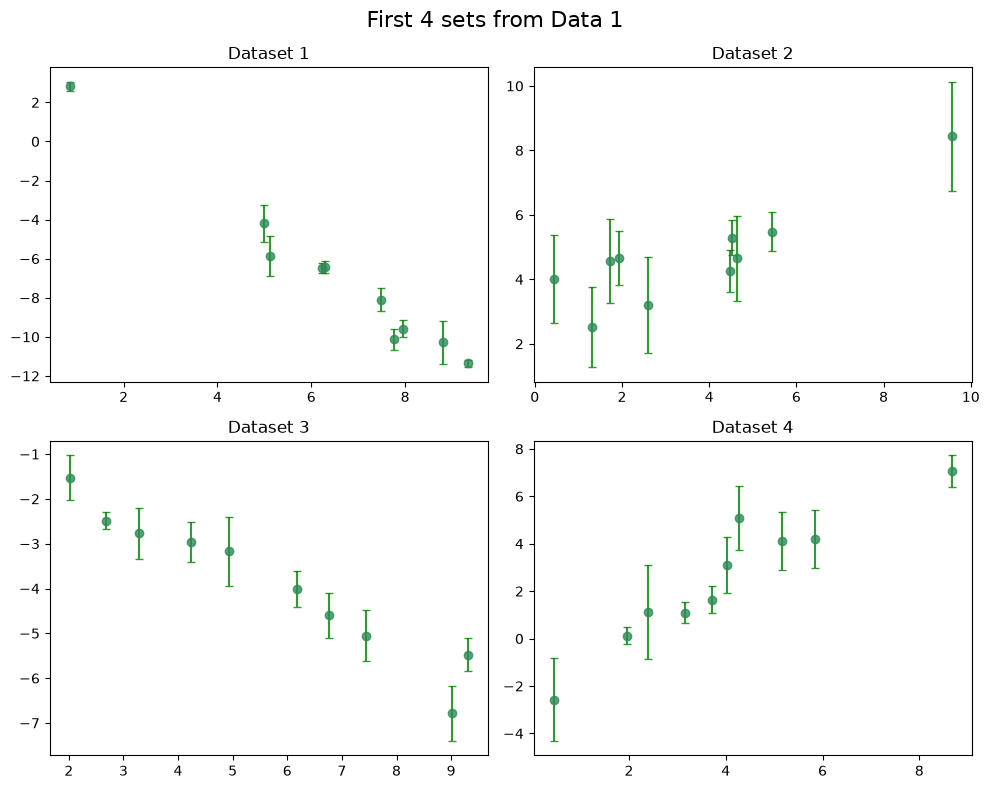

In [23]:
df = pd.read_csv('data1.csv')
datasets = list(df.groupby('dataset'))   

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (ds_id, d) in zip(axes.flat, datasets[:4]):
    ax.errorbar(d['x'], d['y'], yerr=d['sigma'], fmt='o', color='seagreen',
                ecolor='green', capsize=3, alpha=0.8)
    ax.set_title(f'Dataset {ds_id+1}')
plt.suptitle('First 4 sets from Data 1', fontsize=16)    
plt.tight_layout()
plt.show()


a = -1.6626831831611895, b = 3.817560809159585
a = 0.5117862550776586, b = 2.831272857074634
a ranges from -2.014 to 2.173
b ranges from -5.394 to 5.513


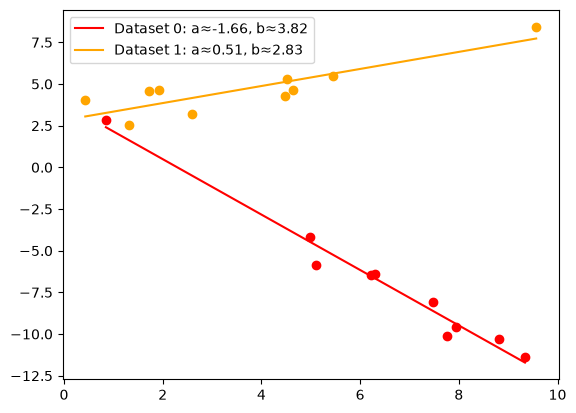

In [24]:
#getting an idea of the range of slopes
a_fits = []
b_fits = []

for ds_id, d in list(datasets)[:]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)

    a_fits.append(a_fit)
    b_fits.append(b_fit)

color = ['red', 'orange']
for ds_id, d in list(datasets)[:2]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)
    plt.plot(d['x'], a_fit * d['x'] + b_fit, label=f'Dataset {ds_id}: a≈{a_fit:.2f}, b≈{b_fit:.2f}', color = color[ds_id])
    plt.plot(d['x'], d['y'], 'o', color = color[ds_id])
    plt.legend()
    print(f'a = {a_fit}, b = {b_fit}')


print(f'a ranges from {min(a_fits):.3f} to {max(a_fits):.3f}')
print(f'b ranges from {min(b_fits):.3f} to {max(b_fits):.3f}')

In [25]:
#Creating a prior for the set based on that range
from sbi.utils import BoxUniform

prior_1 = BoxUniform(low=torch.tensor([-4, -7]), 
                      high=torch.tensor([4, 7]))

prior_samples1 = prior_1.sample((10000,))


In [26]:
#Assuming linear model
n_points = 10  

def simulator(theta, x, sigma):
    coef_a, coef_b = theta[0].item(), theta[1].item()
    sim_noise = np.random.normal(0, sigma, n_points)
    y_sim = coef_a * x + coef_b + sim_noise
    
    obs = np.concatenate([y_sim, x, sigma])
    return torch.tensor(obs, dtype=torch.float32)

n_simulations_per_dataset = 1000   
theta_train = []
x_train = []

for ds_id, d in datasets:
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    thetas = prior_1.sample((n_simulations_per_dataset,))
    for theta in thetas:
        theta_train.append(theta)
        x_train.append(simulator(theta, x, sigma))

theta_train = torch.stack(theta_train)
x_train = torch.stack(x_train)

inference = NPE(prior=prior_1)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)



 Neural network successfully converged after 177 epochs.

 dataset    a_mean    a_std    b_mean    b_std
       0 -1.713349 0.046733  4.169060 0.291956
       1  0.533464 0.160400  2.717465 0.701401
       2 -0.545651 0.053595 -0.950142 0.275649
       3  1.096918 0.108000 -2.071284 0.424239
       4  1.070486 0.102350  2.665337 0.344320
       5  1.957138 0.112563  1.449245 0.366536
       6 -1.554148 0.028344 -1.207932 0.119054
       7 -1.243785 0.128368  3.257827 0.678493
       8  1.457058 0.110578 -4.291461 0.725349
       9  0.552584 0.101364 -3.328884 0.435876
      10 -1.574121 0.081434  4.545971 0.380221
      11  0.077303 0.072233 -4.206330 0.309878
      12 -0.712901 0.212957  1.554095 0.889193
      13  0.191425 0.164904  3.090765 0.650879
      14  0.033599 0.034978  2.492007 0.153751
      15 -1.035557 0.058903 -4.137012 0.324228
      16  0.130568 0.103788 -3.344518 0.737340
      17  0.371363 0.114348 -0.674718 0.337555
      18 -0.794518 0.078524  2.321479 0.602281
      19 -0.994318 0.173242  0.425578 1.085616
      20  1.6

  0%|          | 0/5000 [00:00<?, ?it/s]

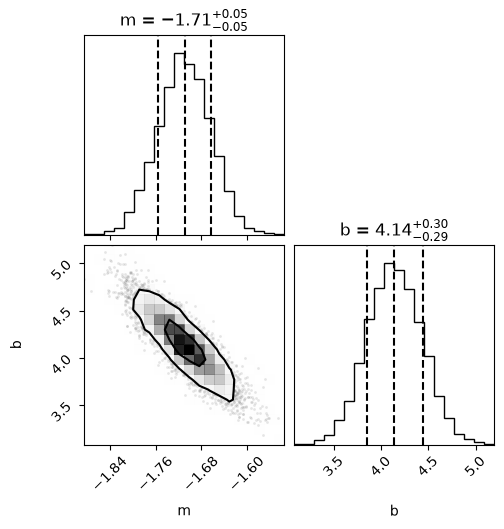

In [27]:
def get_observation(ds_id):
    d = df[df['dataset'] == ds_id]
    y = d['y'].to_numpy()
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    return torch.tensor(np.concatenate([y, x, sigma]), dtype=torch.float32)

#List of a, b found for each dataset 
results_list = []

#Make a nice pretty table for a, b and corresponding sigmas found
for ds_id, d in list(datasets)[:]:
    obs = get_observation(ds_id)
    samples = posterior.sample((1000,), x=obs, show_progress_bars=False)
    posterior_mean = samples.mean(dim=0)
    posterior_std = samples.std(dim=0)
    
    results_list.append({
        'dataset': ds_id,
        'a_mean': posterior_mean[0].item(),
        'a_std': posterior_std[0].item(),
        'b_mean': posterior_mean[1].item(),
        'b_std': posterior_std[1].item(),
    })

results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

#Corner for the first dataset only
ds_id = 0
obs = get_observation(ds_id)
samples = posterior.sample((5000,), x=obs)

flat_samples = samples.numpy()

labels = ["m", "b"]
fig = cp.corner(flat_samples[:, :2], labels=labels, truths=None, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

posterior_mean = samples.mean(dim=0)



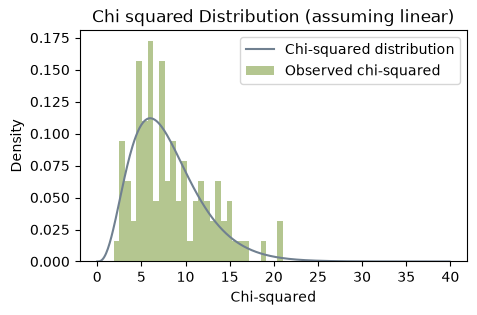

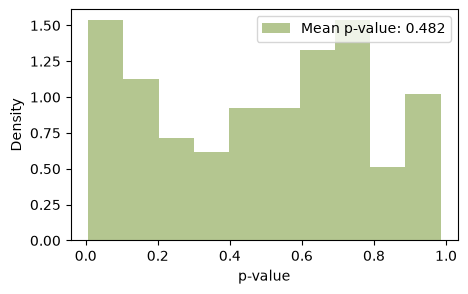

In [28]:
chi2s = []
for ds_id, d in list(datasets)[:]:
    a, b = results_list[ds_id]['a_mean'], results_list[ds_id]['b_mean']

    y_sbi = a * d['x'] + b  
    y_obs = d['y'].to_numpy()
    x_obs = d['x'].to_numpy()
    sigma_obs = d['sigma'].to_numpy()
    chi2 = np.sum(((y_obs - y_sbi) / sigma_obs) ** 2)
    chi2s.append(chi2)

chi2_dist = sp.stats.chi2(df=len(y_obs)-2)

plt.figure(figsize=(5, 3))
plt.plot(np.arange(0, 40, 0.1), chi2_dist.pdf(np.arange(0, 40, 0.1)), color = 'slategray', label='Chi-squared distribution')
plt.hist(chi2s, bins=30, density=True, alpha=0.5, color = 'olivedrab', label='Observed chi-squared')
plt.xlabel('Chi-squared')
plt.ylabel('Density')
plt.legend()
plt.title('Chi squared Distribution (assuming linear)')
plt.show()

pvalues = 1 - chi2_dist.cdf(chi2s)
mean_p = np.mean(pvalues)
plt.figure(figsize=(5, 3))
plt.hist(pvalues, bins=10, density=True, alpha=0.5, color = 'olivedrab',label=f'Mean p-value: {mean_p:.3f}')
plt.xlabel('p-value')
plt.ylabel('Density')
plt.legend()
plt.show()


In [29]:
#Quadratic version
n_points = 10  

def quad_simulator(theta, x, sigma):
    coef_a, coef_b, coef_c = theta[0].item(), theta[1].item(), theta[2].item()
    sim_noise = np.random.normal(0, sigma, n_points)
    y_sim = coef_a * x**2 + coef_b * x + coef_c + sim_noise
    obs = np.concatenate([y_sim, x, sigma])
    return torch.tensor(obs, dtype=torch.float32)

n_simulations_per_dataset = 1000   
theta_train = []
x_train = []

for ds_id, d in datasets:
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    thetas = prior_1.sample((n_simulations_per_dataset,))
    for theta in thetas:
        theta_train.append(theta)
        x_train.append(quad_simulator(theta, x, sigma))

theta_train = torch.stack(theta_train)
x_train = torch.stack(x_train)

inference = NPE(prior=prior_1)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

#List of a, b, c found for each dataset 
results_list = []

#Make a nice pretty table for a, b and corresponding sigmas found
for ds_id, d in list(datasets)[:]:
    obs = get_observation(ds_id)
    samples = posterior.sample((1000,), x=obs, show_progress_bars=False)
    posterior_mean = samples.mean(dim=0)
    posterior_std = samples.std(dim=0)
    
    results_list.append({
        'dataset': ds_id,
        'a_mean': posterior_mean[0].item(),
        'a_std': posterior_std[0].item(),
        'b_mean': posterior_mean[1].item(),
        'b_std': posterior_std[1].item(),
        'c_mean': posterior_mean[2].item(),
        'c_std': posterior_std[2].item(),
    })

results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

#Corner for the first dataset only
ds_id = 0
obs = get_observation(ds_id)
samples = posterior.sample((5000,), x=obs)

flat_samples = samples.numpy()

labels = ["a", "b", "c"]
fig = cp.corner(flat_samples[:, :3], labels=labels, truths=None, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

posterior_mean = samples.mean(dim=0)

IndexError: index 2 is out of bounds for dimension 0 with size 2

In [ ]:
#Quadratic version
chi2s = []
for ds_id, d in list(datasets)[:]:
    a, b, c = results_list[ds_id]['a_mean'], results_list[ds_id]['b_mean'], results_list[ds_id]['c_mean']
    y_fit = a * d['x']**2 + b * d['x'] + c
    y_obs = d['y'].to_numpy()
    x_obs = d['x'].to_numpy()
    sigma_obs = d['sigma'].to_numpy()
    chi2 = np.sum(((y_obs - y_fit) / sigma_obs) ** 2)
    chi2s.append(chi2)

plt.figure(figsize=(5, 3))
plt.plot(np.arange(0, 40, 0.1), chi2_dist.pdf(np.arange(0, 40, 0.1)), color = 'slategray', label='Chi-squared distribution')
plt.hist(chi2s, bins=30, density=True, alpha=0.5, color = 'olivedrab', label='Observed chi-squared')
plt.xlabel('Chi-squared')
plt.ylabel('Density')
plt.title('Chi squared Distribution (assuming quadratic)')
plt.legend()
plt.show()

pvalues = 1 - chi2_dist.cdf(chi2s)
mean_p_1 = np.mean(pvalues)
plt.figure(figsize=(5, 3))
plt.hist(pvalues, bins=10, density=True, alpha=0.5, color = 'olivedrab',label=f'Mean p-value: {mean_p_1:.3f}')
plt.xlabel('p-value')
plt.ylabel('Density')
plt.legend()
plt.show()

In [ ]:
#How good is this fitting? Doing a sort of posterior predictive check
def replicate_posterior(theta_samp, x, sigma):
    theta_np = theta_samp.detach().cpu().numpy()
    m = theta_np[:,0][:, None]
    b = theta_np[:,1][:, None]
    noise = np.random.normal(loc=0,scale=sigma[None,:], size = (len(theta_samp),len(x)))
    y_rep = m * x[None, :] +b +noise
    return y_rep

ds_id = 0

d = df[df['dataset'] == ds_id]

x_obs = d['x'].to_numpy()
y_obs = d['y'].to_numpy()
sigma_obs = d['sigma'].to_numpy()

#get observations from the posterior
obs = get_observation(ds_id)

posterior_samples = posterior.sample((5000,), x=obs,
    show_progress_bars=False)

#replicate data
y_rep = replicate_posterior(posterior_samples, x_obs, sigma_obs)



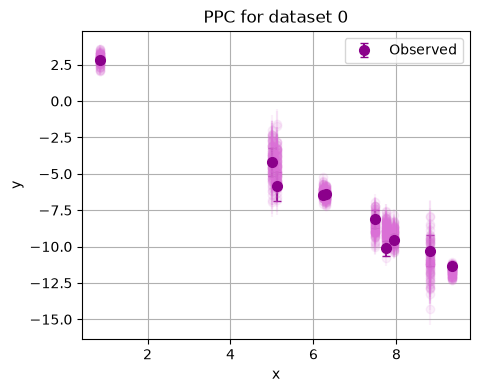

In [ ]:
#plot some subset of replicate data points over 
#the observed data to see how well they match
fig, ax = plt.subplots(figsize=(5, 4))
for i in range(100): ax.errorbar(x_obs, y_rep[i], yerr=sigma_obs, fmt='o',  color='orchid', alpha=0.1)

ax.errorbar(x_obs, y_obs,
    yerr=sigma_obs,
    fmt='o',
    color='darkmagenta',
    capsize=3,
    markersize=7,
    label='Observed')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'PPC for dataset {ds_id}')
ax.grid()
ax.legend()

plt.show()


$p_B$ for mean:0.7868


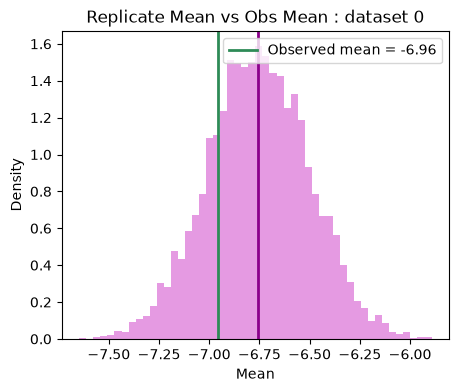

$\Delta$ mean = 0.20


In [ ]:
#Use the mean as a test quantity 
T_obs_mean = np.mean(y_obs)
T_rep_mean = np.mean(y_rep, axis = 1)
p_B_mean = np.mean(T_rep_mean >= T_obs_mean)
T_rep_mean_mean = np.mean(T_rep_mean)

print(fr"$p_B$ for mean:{p_B_mean}")

fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(T_rep_mean, bins=50, density=True, color='orchid', alpha=0.7)

ax.axvline(T_rep_mean_mean, color='darkmagenta', linewidth=2,)
ax.axvline(T_obs_mean, color='seagreen', linewidth=2, label=f'Observed mean = {T_obs_mean:.2f}')

ax.set_xlabel('Mean')
ax.set_ylabel('Density')
ax.set_title(f'Replicate Mean vs Obs Mean : dataset {ds_id}')
ax.legend()

plt.show()

print(fr'$\Delta$ mean = {T_rep_mean_mean-T_obs_mean:.2f}')


p_B for standard deviation: 0.7414


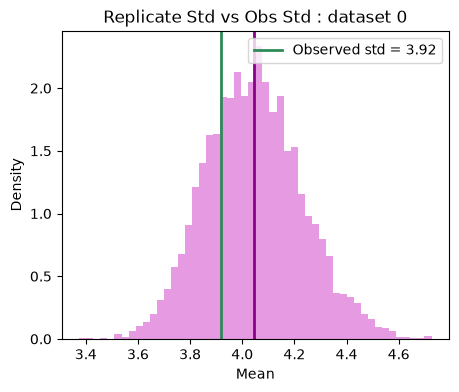

In [ ]:
#do the same for std
T_obs_std = np.std(y_obs)
T_rep_std = np.std(y_rep, axis=1)
T_rep_std_mean = np.mean(T_rep_std)

p_B_std = np.mean(T_rep_std >= T_obs_std)

print("p_B for standard deviation:", p_B_std)
fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(T_rep_std, bins=50, density=True, color='orchid',alpha=0.7)
ax.axvline(T_rep_std_mean,color='darkmagenta',linewidth=2,)

ax.axvline(T_obs_std,color='seagreen',linewidth=2, label=f'Observed std = {T_obs_std:.2f})

ax.set_xlabel('Mean')
ax.set_ylabel('Density')
ax.set_title(f'Replicate Std vs Obs Std : dataset {ds_id}')
ax.legend()

plt.show()


Dataset 2 Analysis

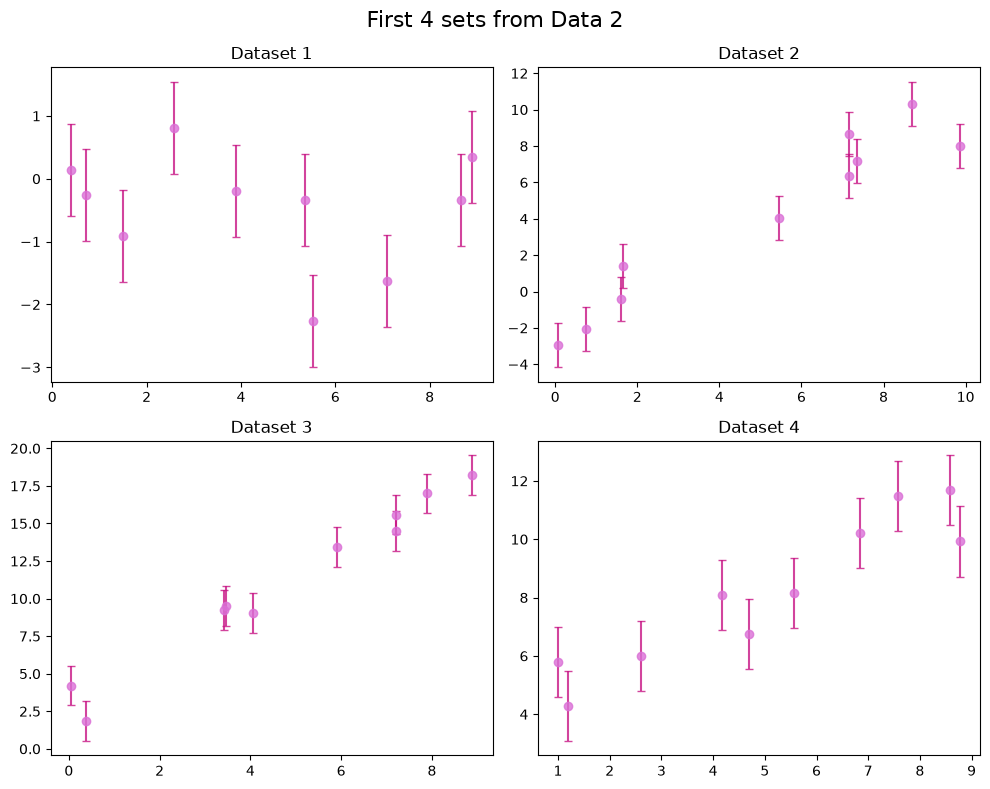

In [ ]:
df = pd.read_csv('data2.csv')
datasets = list(df.groupby('dataset'))   

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (ds_id, d) in zip(axes.flat, datasets[:4]):
    ax.errorbar(d['x'], d['y'], yerr=d['sigma'], fmt='o', color='orchid',
                ecolor='mediumvioletred', capsize=3, alpha=0.8)
    ax.set_title(f'Dataset {ds_id+1}')
plt.suptitle('First 4 sets from Data 2', fontsize=16)    
plt.tight_layout()
plt.show()

a = -0.05870621822704653, b = -0.20185870388723284
a = 1.2724290503034936, b = -2.272903504453701
a ranges from -2.048 to 2.025
b ranges from -5.716 to 6.051


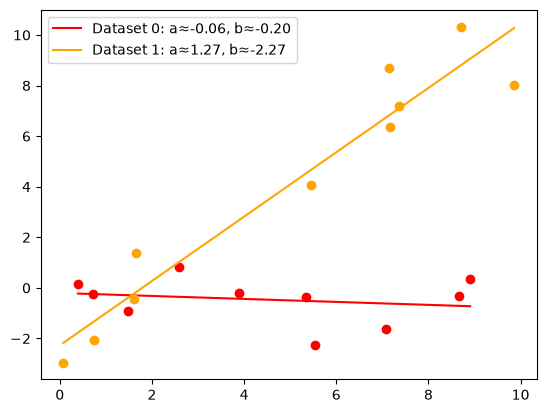

In [ ]:
#getting an idea of the range of slopes
a_fits = []
b_fits = []

for ds_id, d in list(datasets)[:]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)

    a_fits.append(a_fit)
    b_fits.append(b_fit)

color = ['red', 'orange']
for ds_id, d in list(datasets)[:2]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)
    plt.plot(d['x'], a_fit * d['x'] + b_fit, label=f'Dataset {ds_id}: a≈{a_fit:.2f}, b≈{b_fit:.2f}', color = color[ds_id])
    plt.plot(d['x'], d['y'], 'o', color = color[ds_id])
    plt.legend()
    print(f'a = {a_fit}, b = {b_fit}')


print(f'a ranges from {min(a_fits):.3f} to {max(a_fits):.3f}')
print(f'b ranges from {min(b_fits):.3f} to {max(b_fits):.3f}')

In [ ]:
#Creating a prior for the set based on that range
from sbi.utils import BoxUniform

prior_2 = BoxUniform(low=torch.tensor([-3, -8]), 
                      high=torch.tensor([3, 8]))

prior_samples2 = prior_2.sample((10000,))

In [ ]:
#Assuming linear model
n_points = 10  

def simulator(theta, x, sigma):
    coef_a, coef_b = theta[0].item(), theta[1].item()
    sim_noise = np.random.normal(0, sigma, n_points)
    y_sim = coef_a * x + coef_b + sim_noise
    
    obs = np.concatenate([y_sim, x, sigma])
    return torch.tensor(obs, dtype=torch.float32)

n_simulations_per_dataset = 1000   
theta_train = []
x_train = []

for ds_id, d in datasets:
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    thetas = prior_2.sample((n_simulations_per_dataset,))
    for theta in thetas:
        theta_train.append(theta)
        x_train.append(simulator(theta, x, sigma))

theta_train = torch.stack(theta_train)
x_train = torch.stack(x_train)

inference = NPE(prior=prior_2)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 84 epochs.

 dataset    a_mean    a_std    b_mean    b_std
       0 -0.060928 0.080376 -0.134782 0.421853
       1  1.287626 0.112557 -2.285637 0.700273
       2  1.757088 0.144896  2.751316 0.800449
       3  0.825776 0.133921  4.096014 0.775294
       4 -0.630504 0.159980 -0.844536 0.825402
       5  0.651725 0.096026  4.136638 0.446703
       6  1.037658 0.059851 -2.342098 0.401836
       7  1.311505 0.084075 -3.746129 0.633293
       8  0.260052 0.078656  0.101923 0.369162
       9  1.448956 0.223369 -5.255489 1.068692
      10  1.172706 0.140270 -1.136270 0.803334
      11  1.177040 0.167978 -1.163118 1.349445
      12 -0.088037 0.158630 -5.507598 1.066273
      13  1.774352 0.070916  1.332255 0.390438
      14  1.285750 0.155109 -2.815575 0.787684
      15 -1.209501 0.037409 -2.900693 0.218758
      16 -1.247868 0.090310  1.310422 0.505832
      17 -0.504882 0.149722 -1.824588 0.553709
      18  0.297949 0.137747  5.981118 0.861365
      19  0.606057 0.140658  0.960989 0.664692
      20  1.8

  0%|          | 0/5000 [00:00<?, ?it/s]

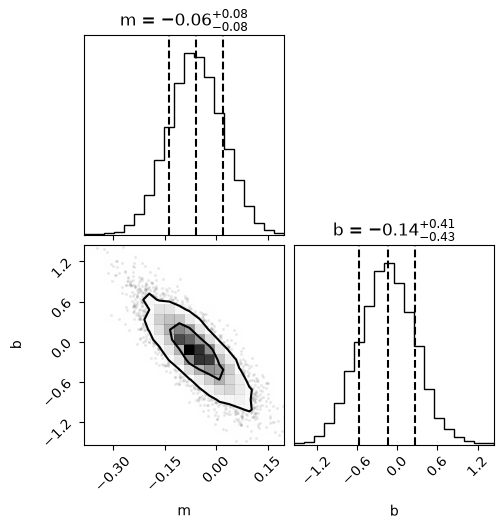

In [ ]:
def get_observation(ds_id):
    d = df[df['dataset'] == ds_id]
    y = d['y'].to_numpy()
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    return torch.tensor(np.concatenate([y, x, sigma]), dtype=torch.float32)

#List of a, b found for each dataset 
results_list = []

#Make a nice pretty table for a, b and corresponding sigmas found
for ds_id, d in list(datasets)[:]:
    obs = get_observation(ds_id)
    samples = posterior.sample((1000,), x=obs, show_progress_bars=False)
    posterior_mean = samples.mean(dim=0)
    posterior_std = samples.std(dim=0)
    
    results_list.append({
        'dataset': ds_id,
        'a_mean': posterior_mean[0].item(),
        'a_std': posterior_std[0].item(),
        'b_mean': posterior_mean[1].item(),
        'b_std': posterior_std[1].item(),
    })

results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

#Corner for the first dataset only
ds_id = 0
obs = get_observation(ds_id)
samples = posterior.sample((5000,), x=obs)

flat_samples = samples.numpy()

labels = ["m", "b"]
fig = cp.corner(flat_samples[:, :2], labels=labels, truths=None, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

posterior_mean = samples.mean(dim=0)



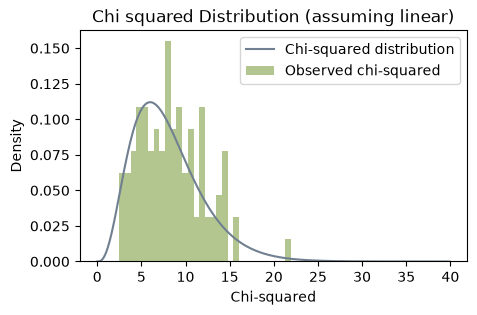

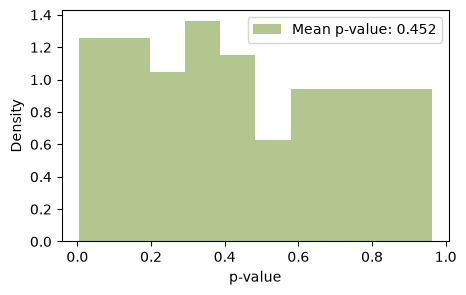

In [ ]:
chi2s = []
for ds_id, d in list(datasets)[:]:
    a, b = results_list[ds_id]['a_mean'], results_list[ds_id]['b_mean']

    y_sbi = a * d['x'] + b  
    y_obs = d['y'].to_numpy()
    x_obs = d['x'].to_numpy()
    sigma_obs = d['sigma'].to_numpy()
    chi2 = np.sum(((y_obs - y_sbi) / sigma_obs) ** 2)
    chi2s.append(chi2)

chi2_dist = sp.stats.chi2(df=len(y_obs)-2)

plt.figure(figsize=(5, 3))
plt.plot(np.arange(0, 40, 0.1), chi2_dist.pdf(np.arange(0, 40, 0.1)), color = 'slategray', label='Chi-squared distribution')
plt.hist(chi2s, bins=30, density=True, alpha=0.5, color = 'olivedrab', label='Observed chi-squared')
plt.xlabel('Chi-squared')
plt.ylabel('Density')
plt.legend()
plt.title('Chi squared Distribution (assuming linear)')
plt.show()

pvalues = 1 - chi2_dist.cdf(chi2s)
mean_p = np.mean(pvalues)
plt.figure(figsize=(5, 3))
plt.hist(pvalues, bins=10, density=True, alpha=0.5, color = 'olivedrab',label=f'Mean p-value: {mean_p:.3f}')
plt.xlabel('p-value')
plt.ylabel('Density')
plt.legend()
plt.show()

In [ ]:
#Quadratic version
n_points = 10  

def quad_simulator(theta, x, sigma):
    coef_a, coef_b, coef_c = theta[0].item(), theta[1].item(), theta[2].item()
    sim_noise = np.random.normal(0, sigma, n_points)
    y_sim = coef_a * x**2 + coef_b * x + coef_c + sim_noise
    obs = np.concatenate([y_sim, x, sigma])
    return torch.tensor(obs, dtype=torch.float32)

n_simulations_per_dataset = 1000   
theta_train = []
x_train = []

for ds_id, d in datasets:
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    thetas = prior_2.sample((n_simulations_per_dataset,))
    for theta in thetas:
        theta_train.append(theta)
        x_train.append(quad_simulator(theta, x, sigma))

theta_train = torch.stack(theta_train)
x_train = torch.stack(x_train)

inference = NPE(prior=prior_2)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

#List of a, b, c found for each dataset 
results_list = []

#Make a nice pretty table for a, b and corresponding sigmas found
for ds_id, d in list(datasets)[:]:
    obs = get_observation(ds_id)
    samples = posterior.sample((1000,), x=obs, show_progress_bars=False)
    posterior_mean = samples.mean(dim=0)
    posterior_std = samples.std(dim=0)
    
    results_list.append({
        'dataset': ds_id,
        'a_mean': posterior_mean[0].item(),
        'a_std': posterior_std[0].item(),
        'b_mean': posterior_mean[1].item(),
        'b_std': posterior_std[1].item(),
        'c_mean': posterior_mean[2].item(),
        'c_std': posterior_std[2].item(),
    })

results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

#Corner for the first dataset only
ds_id = 0
obs = get_observation(ds_id)
samples = posterior.sample((5000,), x=obs)

flat_samples = samples.numpy()

labels = ["a", "b", "c"]
fig = cp.corner(flat_samples[:, :3], labels=labels, truths=None, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

posterior_mean = samples.mean(dim=0)


In [ ]:
#Quadratic version
chi2s = []
for ds_id, d in list(datasets)[:]:
    a, b, c = results_list[ds_id]['a_mean'], results_list[ds_id]['b_mean'], results_list[ds_id]['c_mean']
    y_fit = a * d['x']**2 + b * d['x'] + c
    y_obs = d['y'].to_numpy()
    x_obs = d['x'].to_numpy()
    sigma_obs = d['sigma'].to_numpy()
    chi2 = np.sum(((y_obs - y_fit) / sigma_obs) ** 2)
    chi2s.append(chi2)

plt.figure(figsize=(5, 3))
plt.plot(np.arange(0, 40, 0.1), chi2_dist.pdf(np.arange(0, 40, 0.1)), color = 'slategray', label='Chi-squared distribution')
plt.hist(chi2s, bins=30, density=True, alpha=0.5, color = 'olivedrab', label='Observed chi-squared')
plt.xlabel('Chi-squared')
plt.ylabel('Density')
plt.title('Chi squared Distribution (assuming quadratic)')
plt.legend()
plt.show()

pvalues = 1 - chi2_dist.cdf(chi2s)
mean_p_2 = np.mean(pvalues)
plt.figure(figsize=(5, 3))
plt.hist(pvalues, bins=10, density=True, alpha=0.5, color = 'olivedrab',label=f'Mean p-value: {mean_p_2:.3f}')
plt.xlabel('p-value')
plt.ylabel('Density')
plt.legend()
plt.show()

In [ ]:
#posterior predictive check for data2
def replicate_posterior(theta_samp, x, sigma):
    theta_np = theta_samp.detach().cpu().numpy()
    m = theta_np[:,0][:, None]
    b = theta_np[:,1][:, None]
    noise = np.random.normal(loc=0,scale=sigma[None,:], size = (len(theta_samp),len(x)))
    y_rep = m * x[None, :] +b +noise
    return y_rep

ds_id = 0

d = df[df['dataset'] == ds_id]

x_obs = d['x'].to_numpy()
y_obs = d['y'].to_numpy()
sigma_obs = d['sigma'].to_numpy()

#get observations from the posterior
obs = get_observation(ds_id)

posterior_samples = posterior.sample((5000,), x=obs,
    show_progress_bars=False)

#replicate data
y_rep = replicate_posterior(posterior_samples, x_obs, sigma_obs)


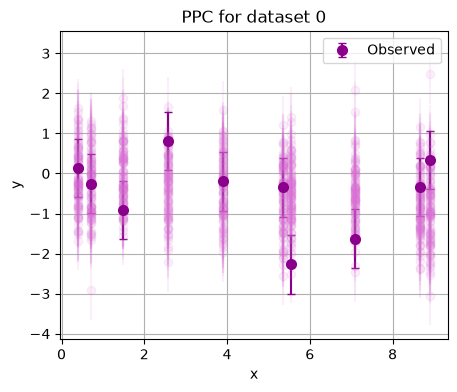

In [ ]:
#plot some subset of replicate data points over 
#the observed data to see how well they match
fig, ax = plt.subplots(figsize=(5, 4))
for i in range(100):
    ax.errorbar(x_obs,
        y_rep[i],
        yerr=sigma_obs,
        fmt='o',
        color='orchid',
        alpha=0.1
    )

ax.errorbar(x_obs,
    y_obs,
    yerr=sigma_obs,
    fmt='o',
    color='darkmagenta',
    capsize=3,
    markersize=7,
    label='Observed'
)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'PPC for dataset {ds_id}')
ax.grid()
ax.legend()

plt.show()


$p_B$ for mean:0.5806


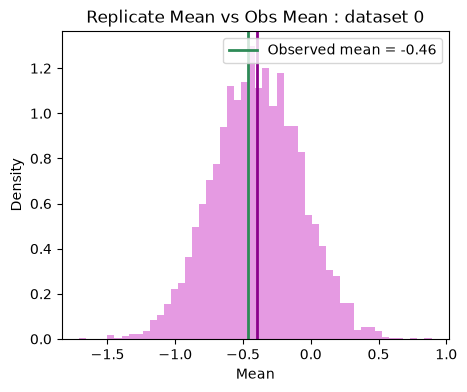

$\Delta$ mean = 0.07


In [ ]:
#Use the mean as a test quantity 
T_obs_mean = np.mean(y_obs)
T_rep_mean = np.mean(y_rep, axis = 1)
p_B_mean = np.mean(T_rep_mean >= T_obs_mean)
T_rep_mean_mean = np.mean(T_rep_mean)

print(fr"$p_B$ for mean:{p_B_mean}")

fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(T_rep_mean,
    bins=50,
    density=True,
    color='orchid',
    alpha=0.7
)

ax.axvline(T_rep_mean_mean,
    color='darkmagenta',
    linewidth=2,
)
ax.axvline(T_obs_mean,
    color='seagreen',
    linewidth=2,
    label=f'Observed mean = {T_obs_mean:.2f}'
)

ax.set_xlabel('Mean')
ax.set_ylabel('Density')
ax.set_title(f'Replicate Mean vs Obs Mean : dataset {ds_id}')
ax.legend()

plt.show()

print(fr'$\Delta$ mean = {T_rep_mean_mean-T_obs_mean:.2f}')


p_B for standard deviation: 0.2546


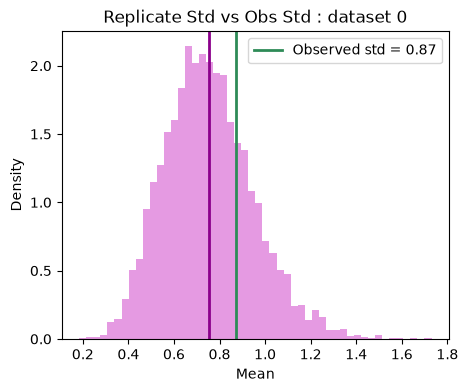

In [ ]:
#do the same for std
T_obs_std = np.std(y_obs)
T_rep_std = np.std(y_rep, axis=1)
T_rep_std_mean = np.mean(T_rep_std)

p_B_std = np.mean(T_rep_std >= T_obs_std)

print("p_B for standard deviation:", p_B_std)
fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(T_rep_std,
    bins=50,
    density=True,
    color='orchid',
    alpha=0.7
)
ax.axvline(T_rep_std_mean,
    color='darkmagenta',
    linewidth=2,
)

ax.axvline(T_obs_std,
    color='seagreen',
    linewidth=2,
    label=f'Observed std = {T_obs_std:.2f}'
)

ax.set_xlabel('Mean')
ax.set_ylabel('Density')
ax.set_title(f'Replicate Std vs Obs Std : dataset {ds_id}')
ax.legend()

plt.show()


Dataset 3 Analysis

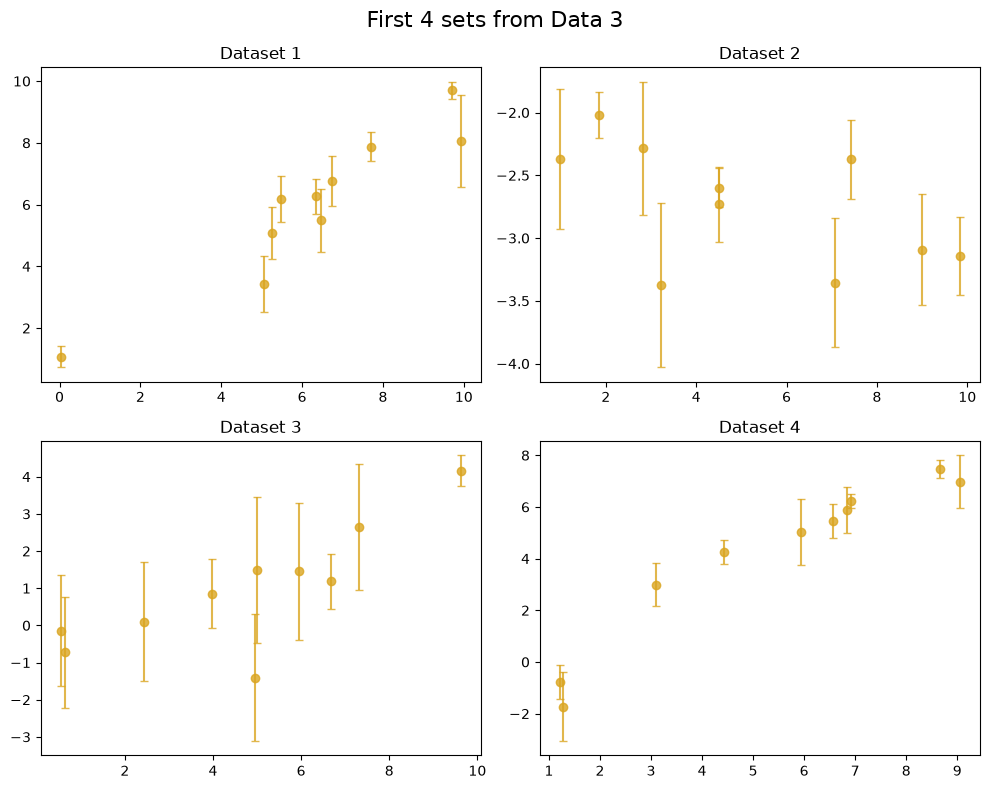

In [ ]:
df = pd.read_csv('data3.csv')
datasets = list(df.groupby('dataset'))   

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (ds_id, d) in zip(axes.flat, datasets[:4]):
    ax.errorbar(d['x'], d['y'], yerr=d['sigma'], fmt='o', color='goldenrod',
                ecolor='goldenrod', capsize=3, alpha=0.8)
    ax.set_title(f'Dataset {ds_id+1}')
plt.suptitle('First 4 sets from Data 3', fontsize=16)    
plt.tight_layout()
plt.show()

a = 0.831741863756199, b = 0.7786789187407074
a = -0.08873758170742081, b = -2.279883113347441
a ranges from -3.067 to 2.161
b ranges from -7.046 to 7.129


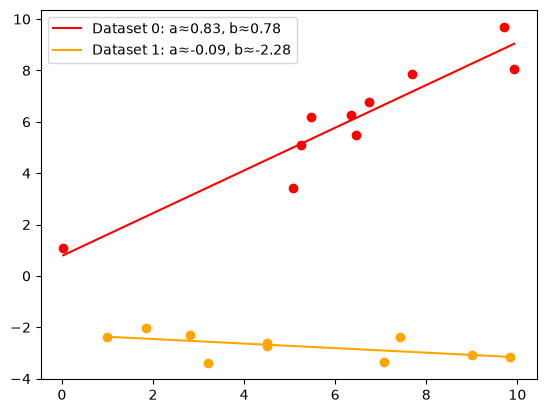

In [ ]:
#getting an idea of the range of slopes
a_fits = []
b_fits = []

for ds_id, d in list(datasets)[:]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)

    a_fits.append(a_fit)
    b_fits.append(b_fit)

color = ['red', 'orange']
for ds_id, d in list(datasets)[:2]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)
    plt.plot(d['x'], a_fit * d['x'] + b_fit, label=f'Dataset {ds_id}: a≈{a_fit:.2f}, b≈{b_fit:.2f}', color = color[ds_id])
    plt.plot(d['x'], d['y'], 'o', color = color[ds_id])
    plt.legend()
    print(f'a = {a_fit}, b = {b_fit}')


print(f'a ranges from {min(a_fits):.3f} to {max(a_fits):.3f}')
print(f'b ranges from {min(b_fits):.3f} to {max(b_fits):.3f}')


In [ ]:
#Creating a prior for the set based on that range

prior_3 = BoxUniform(low=torch.tensor([-3, -7]), 
                      high=torch.tensor([4, 7]))

prior_samples3 = prior_3.sample((10000,))

In [ ]:
n_points = 10  

def simulator(theta, x, sigma):
    coef_a, coef_b = theta[0].item(), theta[1].item()
    sim_noise = np.random.normal(0, sigma, n_points)
    y_sim = coef_a * x + coef_b + sim_noise
    
    obs = np.concatenate([y_sim, x, sigma])
    return torch.tensor(obs, dtype=torch.float32)

n_simulations_per_dataset = 1000   
theta_train = []
x_train = []

for ds_id, d in datasets:
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    thetas = prior_3.sample((n_simulations_per_dataset,))
    for theta in thetas:
        theta_train.append(theta)
        x_train.append(simulator(theta, x, sigma))

theta_train = torch.stack(theta_train)
x_train = torch.stack(x_train)

inference = NPE(prior=prior_3)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 220 epochs.

 dataset    a_mean    a_std    b_mean    b_std
       0  0.892925 0.054023  0.661213 0.416287
       1 -0.117458 0.040179 -2.012489 0.221828
       2  0.555221 0.104631 -1.465761 0.831205
       3  1.027506 0.086228 -1.220663 0.589009
       4 -0.582426 0.069303 -2.494560 0.404874
       5  0.430305 0.124924  3.928355 0.683180
       6  0.503214 0.212570  4.540742 1.245825
       7  0.707767 0.068368 -1.498443 0.311583
       8  2.080297 0.103118  3.364966 0.722256
       9  0.186337 0.173722 -0.570785 1.024377
      10 -0.739004 0.168935 -1.844019 1.256595
      11 -1.273373 0.127077 -0.265197 0.679930
      12 -0.793112 0.139187  2.786942 0.821427
      13  0.749334 0.106652  1.516209 0.737801
      14 -1.323951 0.060894 -0.013630 0.355334
      15  1.187261 0.164333 -0.151464 0.927585
      16  0.705883 0.197384 -0.065908 1.221625
      17 -1.281591 0.041649 -0.328246 0.188272
      18  0.040141 0.153443 -2.878133 0.805484
      19 -1.341465 0.046324 -2.499851 0.264621
      20 -0.4

  0%|          | 0/5000 [00:00<?, ?it/s]

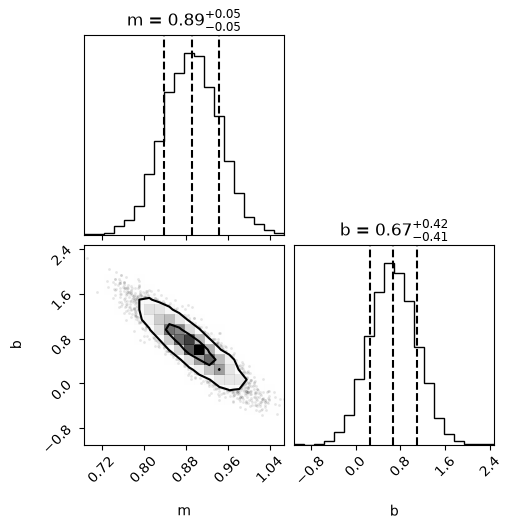

In [ ]:
def get_observation(ds_id):
    d = df[df['dataset'] == ds_id]
    y = d['y'].to_numpy()
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    return torch.tensor(np.concatenate([y, x, sigma]), dtype=torch.float32)

#List of a, b found for each dataset 
results_list = []

#Make a nice pretty table for a, b and corresponding sigmas found
for ds_id, d in list(datasets)[:]:
    obs = get_observation(ds_id)
    samples = posterior.sample((1000,), x=obs, show_progress_bars=False)
    posterior_mean = samples.mean(dim=0)
    posterior_std = samples.std(dim=0)
    
    results_list.append({
        'dataset': ds_id,
        'a_mean': posterior_mean[0].item(),
        'a_std': posterior_std[0].item(),
        'b_mean': posterior_mean[1].item(),
        'b_std': posterior_std[1].item(),
    })

results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

#Corner for the first dataset only
ds_id = 0
obs = get_observation(ds_id)
samples = posterior.sample((5000,), x=obs)

flat_samples = samples.numpy()

labels = ["m", "b"]
fig = cp.corner(flat_samples[:, :2], labels=labels, truths=None, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

posterior_mean = samples.mean(dim=0)

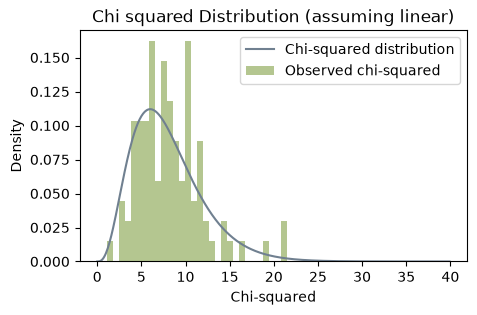

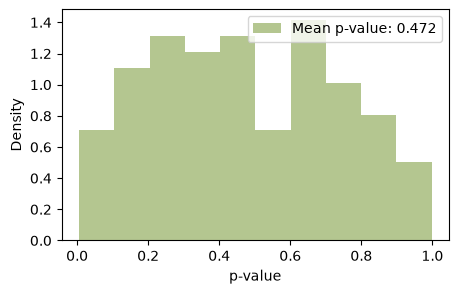

In [ ]:
chi2s = []
for ds_id, d in list(datasets)[:]:
    a, b = results_list[ds_id]['a_mean'], results_list[ds_id]['b_mean']

    y_sbi = a * d['x'] + b  
    y_obs = d['y'].to_numpy()
    x_obs = d['x'].to_numpy()
    sigma_obs = d['sigma'].to_numpy()
    chi2 = np.sum(((y_obs - y_sbi) / sigma_obs) ** 2)
    chi2s.append(chi2)

chi2_dist = sp.stats.chi2(df=len(y_obs)-2)

plt.figure(figsize=(5, 3))
plt.plot(np.arange(0, 40, 0.1), chi2_dist.pdf(np.arange(0, 40, 0.1)), color = 'slategray', label='Chi-squared distribution')
plt.hist(chi2s, bins=30, density=True, alpha=0.5, color = 'olivedrab', label='Observed chi-squared')
plt.xlabel('Chi-squared')
plt.ylabel('Density')
plt.legend()
plt.title('Chi squared Distribution (assuming linear)')
plt.show()

pvalues = 1 - chi2_dist.cdf(chi2s)
mean_p = np.mean(pvalues)
plt.figure(figsize=(5, 3))
plt.hist(pvalues, bins=10, density=True, alpha=0.5, color = 'olivedrab',label=f'Mean p-value: {mean_p:.3f}')
plt.xlabel('p-value')
plt.ylabel('Density')
plt.legend()
plt.show()

In [ ]:
#Quadratic version
n_points = 10  

def quad_simulator(theta, x, sigma):
    coef_a, coef_b, coef_c = theta[0].item(), theta[1].item(), theta[2].item()
    sim_noise = np.random.normal(0, sigma, n_points)
    y_sim = coef_a * x**2 + coef_b * x + coef_c + sim_noise
    obs = np.concatenate([y_sim, x, sigma])
    return torch.tensor(obs, dtype=torch.float32)

n_simulations_per_dataset = 1000   
theta_train = []
x_train = []

for ds_id, d in datasets:
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    thetas = prior_3.sample((n_simulations_per_dataset,))
    for theta in thetas:
        theta_train.append(theta)
        x_train.append(quad_simulator(theta, x, sigma))

theta_train = torch.stack(theta_train)
x_train = torch.stack(x_train)

inference = NPE(prior=prior_3)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

#List of a, b, c found for each dataset 
results_list = []

#Make a nice pretty table for a, b and corresponding sigmas found
for ds_id, d in list(datasets)[:]:
    obs = get_observation(ds_id)
    samples = posterior.sample((1000,), x=obs, show_progress_bars=False)
    posterior_mean = samples.mean(dim=0)
    posterior_std = samples.std(dim=0)
    
    results_list.append({
        'dataset': ds_id,
        'a_mean': posterior_mean[0].item(),
        'a_std': posterior_std[0].item(),
        'b_mean': posterior_mean[1].item(),
        'b_std': posterior_std[1].item(),
        'c_mean': posterior_mean[2].item(),
        'c_std': posterior_std[2].item(),
    })

results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

#Corner for the first dataset only
ds_id = 0
obs = get_observation(ds_id)
samples = posterior.sample((5000,), x=obs)

flat_samples = samples.numpy()

labels = ["a", "b", "c"]
fig = cp.corner(flat_samples[:, :3], labels=labels, truths=None, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

posterior_mean = samples.mean(dim=0)


In [ ]:
#Quadratic version
chi2s = []
for ds_id, d in list(datasets)[:]:
    a, b, c = results_list[ds_id]['a_mean'], results_list[ds_id]['b_mean'], results_list[ds_id]['c_mean']
    y_fit = a * d['x']**2 + b * d['x'] + c
    y_obs = d['y'].to_numpy()
    x_obs = d['x'].to_numpy()
    sigma_obs = d['sigma'].to_numpy()
    chi2 = np.sum(((y_obs - y_fit) / sigma_obs) ** 2)
    chi2s.append(chi2)

plt.figure(figsize=(5, 3))
plt.plot(np.arange(0, 40, 0.1), chi2_dist.pdf(np.arange(0, 40, 0.1)), color = 'slategray', label='Chi-squared distribution')
plt.hist(chi2s, bins=30, density=True, alpha=0.5, color = 'olivedrab', label='Observed chi-squared')
plt.xlabel('Chi-squared')
plt.ylabel('Density')
plt.title('Chi squared Distribution (assuming quadratic)')
plt.legend()
plt.show()

pvalues = 1 - chi2_dist.cdf(chi2s)
mean_p_3 = np.mean(pvalues)
plt.figure(figsize=(5, 3))
plt.hist(pvalues, bins=10, density=True, alpha=0.5, color = 'olivedrab',label=f'Mean p-value: {mean_p_3:.3f}')
plt.xlabel('p-value')
plt.ylabel('Density')
plt.legend()
plt.show()

In [ ]:
#data 3
def replicate_posterior(theta_samp, x, sigma):
    theta_np = theta_samp.detach().cpu().numpy()
    m = theta_np[:,0][:, None]
    b = theta_np[:,1][:, None]
    noise = np.random.normal(loc=0,scale=sigma[None,:], size = (len(theta_samp),len(x)))
    y_rep = m * x[None, :] +b +noise
    return y_rep

ds_id = 0

d = df[df['dataset'] == ds_id]

x_obs = d['x'].to_numpy()
y_obs = d['y'].to_numpy()
sigma_obs = d['sigma'].to_numpy()

#get observations from the posterior
obs = get_observation(ds_id)

posterior_samples = posterior.sample((5000,), x=obs,
    show_progress_bars=False)

#replicate data
y_rep = replicate_posterior(posterior_samples, x_obs, sigma_obs)


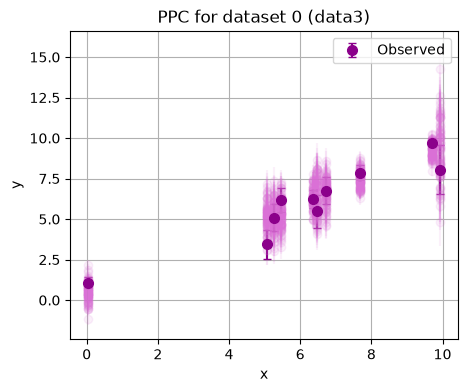

In [ ]:
#plot some subset of replicate data points over 
#the observed data to see how well they match
fig, ax = plt.subplots(figsize=(5, 4))
for i in range(100):
    ax.errorbar(x_obs,
        y_rep[i],
        yerr=sigma_obs,
        fmt='o',
        color='orchid',
        alpha=0.1
    )

ax.errorbar(x_obs,
    y_obs,
    yerr=sigma_obs,
    fmt='o',
    color='darkmagenta',
    capsize=3,
    markersize=7,
    label='Observed'
)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'PPC for dataset {ds_id} (data3)')
ax.grid()
ax.legend()

plt.show()


$p_B$ for mean:0.7268


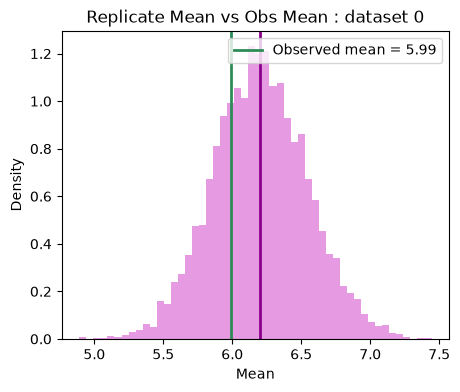

$\Delta$ mean = 0.21


In [ ]:
#Use the mean as a test quantity 
T_obs_mean = np.mean(y_obs)
T_rep_mean = np.mean(y_rep, axis = 1)
p_B_mean = np.mean(T_rep_mean >= T_obs_mean)
T_rep_mean_mean = np.mean(T_rep_mean)

print(fr"$p_B$ for mean:{p_B_mean}")

fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(T_rep_mean,
    bins=50,
    density=True,
    color='orchid',
    alpha=0.7
)

ax.axvline(T_rep_mean_mean,
    color='darkmagenta',
    linewidth=2,
)
ax.axvline(T_obs_mean,
    color='seagreen',
    linewidth=2,
    label=f'Observed mean = {T_obs_mean:.2f}'
)

ax.set_xlabel('Mean')
ax.set_ylabel('Density')
ax.set_title(f'Replicate Mean vs Obs Mean : dataset {ds_id}')
ax.legend()

plt.show()

print(fr'$\Delta$ mean = {T_rep_mean_mean-T_obs_mean:.2f}')


p_B for standard deviation: 0.717


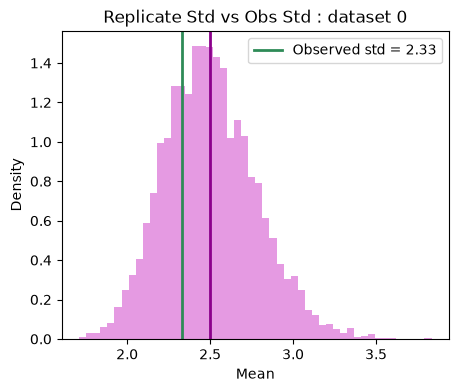

In [ ]:
#do the same for std
T_obs_std = np.std(y_obs)
T_rep_std = np.std(y_rep, axis=1)
T_rep_std_mean = np.mean(T_rep_std)

p_B_std = np.mean(T_rep_std >= T_obs_std)

print("p_B for standard deviation:", p_B_std)
fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(T_rep_std,
    bins=50,
    density=True,
    color='orchid',
    alpha=0.7
)
ax.axvline(T_rep_std_mean,
    color='darkmagenta',
    linewidth=2,
)

ax.axvline(T_obs_std,
    color='seagreen',
    linewidth=2,
    label=f'Observed std = {T_obs_std:.2f}'
)

ax.set_xlabel('Mean')
ax.set_ylabel('Density')
ax.set_title(f'Replicate Std vs Obs Std : dataset {ds_id}')
ax.legend()

plt.show()


Dataset 4 Analysis

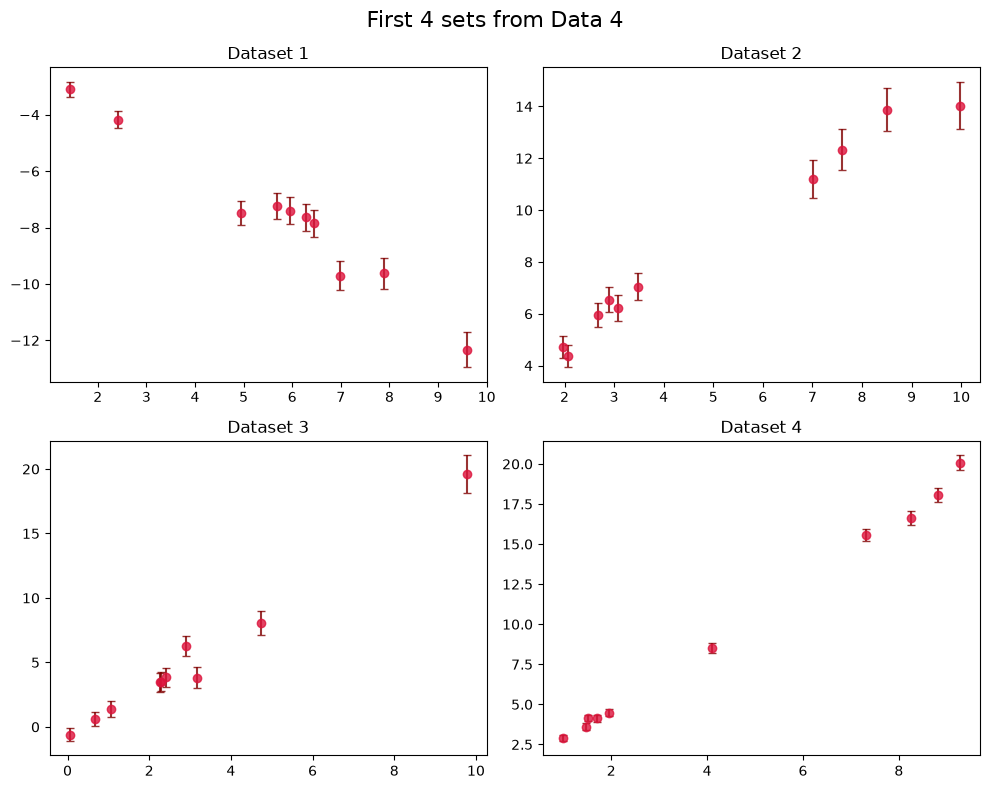

In [ ]:
df = pd.read_csv('data4.csv')
datasets = list(df.groupby('dataset'))   

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (ds_id, d) in zip(axes.flat, datasets[:4]):
    ax.errorbar(d['x'], d['y'], yerr=d['sigma'], fmt='o', color='crimson',
                ecolor='maroon', capsize=3, alpha=0.8)
    ax.set_title(f'Dataset {ds_id+1}')
plt.suptitle('First 4 sets from Data 4', fontsize=16)    
plt.tight_layout()
plt.show()

a = -1.0785345154908206, b = -1.436439410083085
a = 1.2538404780466545, b = 2.4520852111998557
a ranges from -2.127 to 2.190
b ranges from -4.904 to 5.678


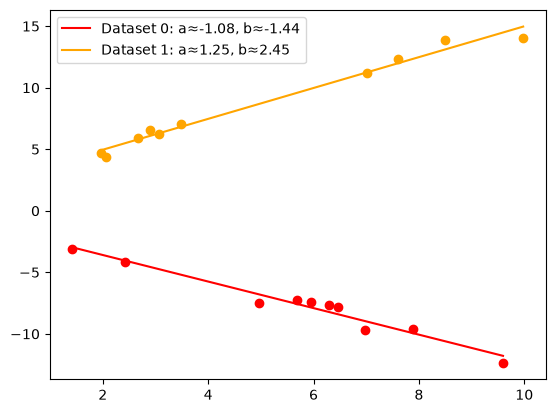

In [ ]:
#getting an idea of the range of slopes
a_fits = []
b_fits = []
#c_fits = []

for ds_id, d in list(datasets)[:]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)

    a_fits.append(a_fit)
    b_fits.append(b_fit)
    #c_fits.append(c_fit)

color = ['red', 'orange']
for ds_id, d in list(datasets)[:2]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)
    plt.plot(d['x'], a_fit * d['x'] + b_fit  , label=f'Dataset {ds_id}: a≈{a_fit:.2f}, b≈{b_fit:.2f}', color = color[ds_id])
    plt.plot(d['x'], d['y'], 'o', color = color[ds_id])
    plt.legend()
    print(f'a = {a_fit}, b = {b_fit}')


print(f'a ranges from {min(a_fits):.3f} to {max(a_fits):.3f}')
print(f'b ranges from {min(b_fits):.3f} to {max(b_fits):.3f}')
#print(f'c ranges from {min(c_fits):.3f} to {max(c_fits):.3f}')

In [ ]:
#Creating a prior for the set based on that range
from sbi.utils import BoxUniform

prior_4 = BoxUniform(low=torch.tensor([-6, -6]), 
                      high=torch.tensor([3, 6]))

prior_samples4 = prior_4.sample((10000,))


In [ ]:
n_points = 10  

def simulator(theta, x, sigma):
    coef_a, coef_b = theta[0].item(), theta[1].item()
    sim_noise = np.random.normal(0, sigma, n_points)
    y_sim = coef_a * x + coef_b + sim_noise

    obs = np.concatenate([y_sim, x, sigma])
    return torch.tensor(obs, dtype=torch.float32)

n_simulations_per_dataset = 1000  
theta_train = []
x_train = []

for ds_id, d in datasets:
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    thetas = prior_4.sample((n_simulations_per_dataset,))
    for theta in thetas:
        theta_train.append(theta)
        x_train.append(simulator(theta, x, sigma))

theta_train = torch.stack(theta_train)
x_train = torch.stack(x_train)

inference = NPE(prior=prior_4)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 84 epochs.

 dataset    a_mean    a_std    b_mean    b_std
       0 -1.042964 0.057563 -1.668479 0.282466
       1  1.338966 0.090093  2.046134 0.359356
       2  1.975301 0.130703 -0.808884 0.335405
       3  1.990833 0.047681  0.783983 0.166107
       4 -0.914742 0.052385 -3.540141 0.236831
       5  2.206098 0.161188  0.687488 0.482806
       6 -1.409336 0.104330 -4.058411 0.512132
       7 -0.717864 0.137982 -3.211510 0.602769
       8  0.860355 0.151888  3.663742 0.935202
       9 -1.798292 0.087509 -4.317471 0.504228
      10 -0.422980 0.116624  1.398902 0.549395
      11 -1.232809 0.101835 -2.580933 0.382575
      12  2.162809 0.119797  1.648382 0.662697
      13 -0.610230 0.084412 -0.651089 0.305428
      14 -0.599248 0.057245  0.335836 0.186193
      15 -0.587496 0.126095  4.465356 0.680251
      16  1.374511 0.063251 -3.128526 0.255172
      17 -0.397700 0.160066  2.727045 0.578371
      18  0.277964 0.111131  4.062568 0.484139
      19 -0.387369 0.166379  4.008499 0.676121
      20 -0.1

  0%|          | 0/5000 [00:00<?, ?it/s]

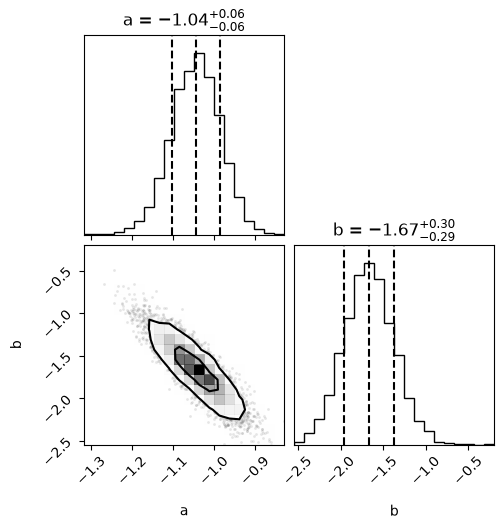

In [ ]:
def get_observation(ds_id):
    d = df[df['dataset'] == ds_id]
    y = d['y'].to_numpy()
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    return torch.tensor(np.concatenate([y, x, sigma]), dtype=torch.float32)

#List of a, b found for each dataset 
results_list = []

#Make a nice pretty table for a, b and corresponding sigmas found
for ds_id, d in list(datasets)[:]:
    obs = get_observation(ds_id)
    samples = posterior.sample((1000,), x=obs, show_progress_bars=False)
    posterior_mean = samples.mean(dim=0)
    posterior_std = samples.std(dim=0)
    
    results_list.append({
        'dataset': ds_id,
        'a_mean': posterior_mean[0].item(),
        'a_std': posterior_std[0].item(),
        'b_mean': posterior_mean[1].item(),
        'b_std': posterior_std[1].item(),
    })

results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

#Corner for the first dataset only
ds_id = 0
obs = get_observation(ds_id)
samples = posterior.sample((5000,), x=obs)

flat_samples = samples.numpy()

labels = ["a", "b"]
fig = cp.corner(flat_samples[:, :2], labels=labels, truths=None, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

posterior_mean = samples.mean(dim=0)

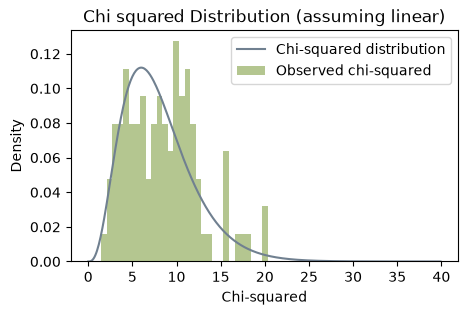

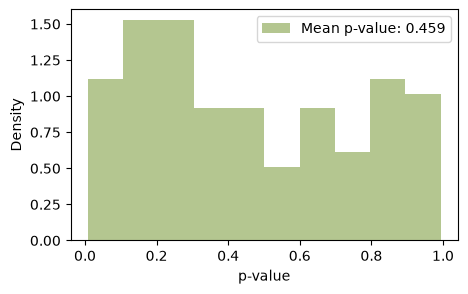

In [ ]:
chi2s = []
for ds_id, d in list(datasets)[:]:
    a, b = results_list[ds_id]['a_mean'], results_list[ds_id]['b_mean']

    y_sbi = a * d['x'] + b  
    y_obs = d['y'].to_numpy()
    x_obs = d['x'].to_numpy()
    sigma_obs = d['sigma'].to_numpy()
    chi2 = np.sum(((y_obs - y_sbi) / sigma_obs) ** 2)
    chi2s.append(chi2)

chi2_dist = sp.stats.chi2(df=len(y_obs)-2)

plt.figure(figsize=(5, 3))
plt.plot(np.arange(0, 40, 0.1), chi2_dist.pdf(np.arange(0, 40, 0.1)), color = 'slategray', label='Chi-squared distribution')
plt.hist(chi2s, bins=30, density=True, alpha=0.5, color = 'olivedrab', label='Observed chi-squared')
plt.xlabel('Chi-squared')
plt.ylabel('Density')
plt.legend()
plt.title('Chi squared Distribution (assuming linear)')
plt.show()

pvalues = 1 - chi2_dist.cdf(chi2s)
mean_p = np.mean(pvalues)
plt.figure(figsize=(5, 3))
plt.hist(pvalues, bins=10, density=True, alpha=0.5, color = 'olivedrab',label=f'Mean p-value: {mean_p:.3f}')
plt.xlabel('p-value')
plt.ylabel('Density')
plt.legend()
plt.show()

In [ ]:
#Quadratic version
n_points = 10  

def quad_simulator(theta, x, sigma):
    coef_a, coef_b, coef_c = theta[0].item(), theta[1].item(), theta[2].item()
    sim_noise = np.random.normal(0, sigma, n_points)
    y_sim = coef_a * x**2 + coef_b * x + coef_c + sim_noise
    obs = np.concatenate([y_sim, x, sigma])
    return torch.tensor(obs, dtype=torch.float32)

n_simulations_per_dataset = 1000   
theta_train = []
x_train = []

for ds_id, d in datasets:
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    thetas = prior_4.sample((n_simulations_per_dataset,))
    for theta in thetas:
        theta_train.append(theta)
        x_train.append(quad_simulator(theta, x, sigma))

theta_train = torch.stack(theta_train)
x_train = torch.stack(x_train)

inference = NPE(prior=prior_4)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

#List of a, b, c found for each dataset 
results_list = []

#Make a nice pretty table for a, b and corresponding sigmas found
for ds_id, d in list(datasets)[:]:
    obs = get_observation(ds_id)
    samples = posterior.sample((1000,), x=obs, show_progress_bars=False)
    posterior_mean = samples.mean(dim=0)
    posterior_std = samples.std(dim=0)
    
    results_list.append({
        'dataset': ds_id,
        'a_mean': posterior_mean[0].item(),
        'a_std': posterior_std[0].item(),
        'b_mean': posterior_mean[1].item(),
        'b_std': posterior_std[1].item(),
        'c_mean': posterior_mean[2].item(),
        'c_std': posterior_std[2].item(),
    })

results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

#Corner for the first dataset only
ds_id = 0
obs = get_observation(ds_id)
samples = posterior.sample((5000,), x=obs)

flat_samples = samples.numpy()

labels = ["a", "b", "c"]
fig = cp.corner(flat_samples[:, :3], labels=labels, truths=None, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

posterior_mean = samples.mean(dim=0)


In [ ]:
#Quadratic version
chi2s = []
for ds_id, d in list(datasets)[:]:
    a, b, c = results_list[ds_id]['a_mean'], results_list[ds_id]['b_mean'], results_list[ds_id]['c_mean']
    y_fit = a * d['x']**2 + b * d['x'] + c
    y_obs = d['y'].to_numpy()
    x_obs = d['x'].to_numpy()
    sigma_obs = d['sigma'].to_numpy()
    chi2 = np.sum(((y_obs - y_fit) / sigma_obs) ** 2)
    chi2s.append(chi2)

plt.figure(figsize=(5, 3))
plt.plot(np.arange(0, 40, 0.1), chi2_dist.pdf(np.arange(0, 40, 0.1)), color = 'slategray', label='Chi-squared distribution')
plt.hist(chi2s, bins=30, density=True, alpha=0.5, color = 'olivedrab', label='Observed chi-squared')
plt.xlabel('Chi-squared')
plt.ylabel('Density')
plt.title('Chi squared Distribution (assuming quadratic)')
plt.legend()
plt.show()

pvalues = 1 - chi2_dist.cdf(chi2s)
mean_p_4 = np.mean(pvalues)
plt.figure(figsize=(5, 3))
plt.hist(pvalues, bins=10, density=True, alpha=0.5, color = 'olivedrab',label=f'Mean p-value: {mean_p_4:.3f}')
plt.xlabel('p-value')
plt.ylabel('Density')
plt.legend()
plt.show()

In [ ]:
def replicate_posterior(theta_samp, x, sigma):
    theta_np = theta_samp.detach().cpu().numpy()
    m = theta_np[:,0][:, None]
    b = theta_np[:,1][:, None]
    noise = np.random.normal(loc=0,scale=sigma[None,:], size = (len(theta_samp),len(x)))
    y_rep = m * x[None, :] +b +noise
    return y_rep

ds_id = 0

d = df[df['dataset'] == ds_id]

x_obs = d['x'].to_numpy()
y_obs = d['y'].to_numpy()
sigma_obs = d['sigma'].to_numpy()

#get observations from the posterior
obs = get_observation(ds_id)

posterior_samples = posterior.sample((5000,), x=obs,
    show_progress_bars=False)

#replicate data
y_rep = replicate_posterior(posterior_samples, x_obs, sigma_obs)


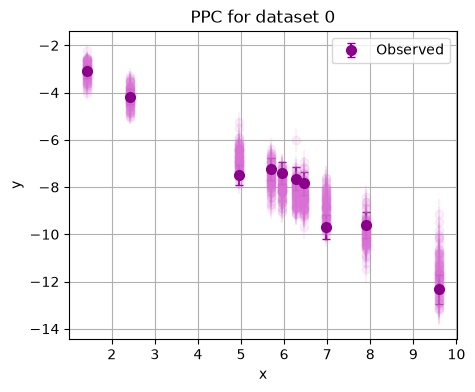

In [ ]:
#plot some subset of replicate data points over 
#the observed data to see how well they match
fig, ax = plt.subplots(figsize=(5, 4))
for i in range(100):
    ax.errorbar(x_obs,
        y_rep[i],
        yerr=sigma_obs,
        fmt='o',
        color='orchid',
        alpha=0.1
    )

ax.errorbar(x_obs,
    y_obs,
    yerr=sigma_obs,
    fmt='o',
    color='darkmagenta',
    capsize=3,
    markersize=7,
    label='Observed'
)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'PPC for dataset {ds_id}')
ax.grid()
ax.legend()

plt.show()


$p_B$ for mean:0.4898


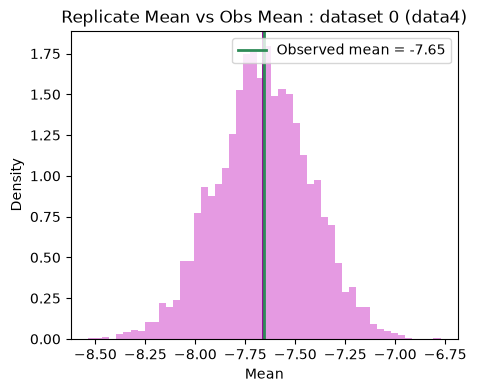

$\Delta$ mean = -0.01


In [ ]:
#Use the mean as a test quantity 
T_obs_mean = np.mean(y_obs)
T_rep_mean = np.mean(y_rep, axis = 1)
p_B_mean = np.mean(T_rep_mean >= T_obs_mean)
T_rep_mean_mean = np.mean(T_rep_mean)

print(fr"$p_B$ for mean:{p_B_mean}")

fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(T_rep_mean,
    bins=50,
    density=True,
    color='orchid',
    alpha=0.7
)

ax.axvline(T_rep_mean_mean,
    color='darkmagenta',
    linewidth=2,
)
ax.axvline(T_obs_mean,
    color='seagreen',
    linewidth=2,
    label=f'Observed mean = {T_obs_mean:.2f}'
)

ax.set_xlabel('Mean')
ax.set_ylabel('Density')
ax.set_title(f'Replicate Mean vs Obs Mean : dataset {ds_id} (data4)')
ax.legend()

plt.show()

print(fr'$\Delta$ mean = {T_rep_mean_mean-T_obs_mean:.2f}')


p_B for standard deviation: 0.3472


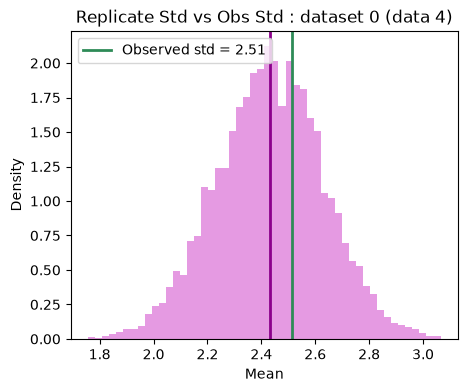

In [ ]:
#do the same for std
T_obs_std = np.std(y_obs)
T_rep_std = np.std(y_rep, axis=1)
T_rep_std_mean = np.mean(T_rep_std)

p_B_std = np.mean(T_rep_std >= T_obs_std)

print("p_B for standard deviation:", p_B_std)
fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(T_rep_std,
    bins=50,
    density=True,
    color='orchid',
    alpha=0.7
)
ax.axvline(T_rep_std_mean,
    color='darkmagenta',
    linewidth=2,
)

ax.axvline(T_obs_std,
    color='seagreen',
    linewidth=2,
    label=f'Observed std = {T_obs_std:.2f}'
)

ax.set_xlabel('Mean')
ax.set_ylabel('Density')
ax.set_title(f'Replicate Std vs Obs Std : dataset {ds_id} (data 4)')
ax.legend()

plt.show()


In [ ]:
#Comparing all four p-values
print(f"Mean p-values for datasets 1-4 assuming linear model: 0.487, 0.452, 0.472, 0.459")
print(f'end=> Mean p-values for datasets 1-4 assuming quadratic model: {mean_p_1:.3f}, {mean_p_2:.3f}, {mean_p_3:.3f}, {mean_p_4:.3f}')
delta_p_1 = mean_p_1 - 0.487
delta_p_2 = mean_p_2 - 0.452
delta_p_3 = mean_p_3 - 0.472
delta_p_4 = mean_p_4 - 0.459
print(f'When changing from linear to quadratic model, p-values change by: {delta_p_1:.3f}, {delta_p_2:.3f}, {delta_p_3:.3f}, {delta_p_4:.3f}')

Mean p-values for datasets 1-4: 0.487, 0.452, 0.472, 0.459


Dataset 2 has the lowest p-value, 


2- homog
1 -hetero
4 -x dep
3 - 2nd degree